## plot the pedogogical figure for redshift errors

In [1]:
import numpy as np
import os, sys
import matplotlib.pyplot as plt

sys.path.append('../../')
from helper import REDSHIFT_BIN_GLOBAL
from plotting_tools import COLOR_OVERALL
%load_ext autoreload
%autoreload 2
%matplotlib inline

In [98]:
args_scatter = dict(
    alpha = 0.7,
    # color = 'grey',
    # s=15,
    linewidths=0.8,
    edgecolor='none',
    zorder=1,
)
args_line = dict(
    alpha = 0.9,
    ls = '--',
    lw = 1, 
    zorder=2,
)
args_arrow = dict(
    alpha=0.6,
    ls = '--',
    lw = 2, 
    zorder =2,
)

/tmp/ipykernel_1582543/3857090118.py:36: UserWarning: You passed a edgecolor/edgecolors ('none') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax.scatter(z_true_rand, z_obs_rand, marker='x',color='maroon',**args_scatter )
/tmp/ipykernel_1582543/3857090118.py:55: UserWarning: You passed a edgecolor/edgecolors ('none') for an unfilled marker ('+').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax.scatter(z_true_conf, z_obs_conf,marker='+', color = 'darkblue', **args_scatter)
/tmp/ipykernel_1582543/3857090118.py:55: UserWarning: You passed a edgecolor/edgecolors ('none') for an unfilled marker ('+').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax.scatter(z_true_conf, z_obs_conf,marker='+', color = 'darkblue', **args_scatter)


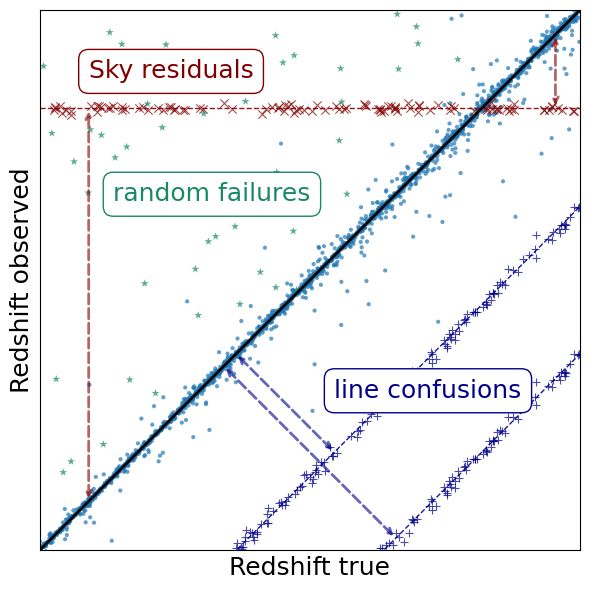

In [113]:
zmin, zmax = 0.0, 2.2
z = np.linspace(zmin, zmax, 100)

tracer = ['BGS', 'LRG', 'ELG', 'QSO']

offset = dict(BGS=-0.0, LRG=0.01, ELG=+0.02, QSO=+0.03)

fig, ax = plt.subplots(figsize=(6, 6))
# 1:1 line
# ax.plot(z, z, ls='-', lw=2, color='k')

# Number of mock points
N = 2000
z_true_rand = np.random.uniform(zmin, zmax, N)
rng = np.random.default_rng(0)
gamma0 = 0.01/3       
gamma1 = 0.02/3   
gamma = gamma0 + gamma1 * (z_true_rand / zmax)
dz = rng.standard_cauchy(N) * gamma
# dz = np.clip(dz, -0.25, 0.25)
z_obs_rand = z_true_rand + dz
ax.scatter(z_true_rand, z_obs_rand, marker='.', **args_scatter)
# ax.plot(z, 1.01 * z+0.04, color="#188967" , lw=1.5, ls=':')
# ax.plot(z, 0.99 * z-0.04, color="#188967" ,lw=1.5, ls=':')
# ax.text(zmax/2+0.25, zmax/2+0.1, 'redshift uncertainty', color="#188967", 
#         bbox=dict(facecolor='white',edgecolor="#188967",boxstyle='round,pad=0.4',linewidth=1.0),
#         fontsize=18, ha='left',va='center')
ax.plot(z, z, ls='-', lw=2, color='k')

# sky residuals
N = 100
z_sky = 1.8
z_true_rand = np.random.uniform(zmin, zmax, N)
sigma_z = 0.01   # controls thickness of the band
z_obs_rand = rng.normal(loc=z_sky, scale=sigma_z, size=N)
ax.scatter(z_true_rand, z_obs_rand, marker='x',color='maroon',**args_scatter )
ax.axhline(z_sky,color='maroon',**args_line)
# ax.axhline(z_sky-0.03,color='maroon',**args_line)
for indx, x0 in enumerate([0.2, 2.1]):
    dz_sky = z_sky-x0  
    ax.annotate("",xy=(x0, x0 + dz_sky), xytext=(x0, x0),        # true solution on z=z
        arrowprops=dict(arrowstyle='<->', color = 'maroon', **args_arrow))
    if indx == 0: ax.text(x0,  z_sky+0.15, 'Sky residuals', 
                          bbox=dict(facecolor='white',edgecolor='maroon',boxstyle='round,pad=0.4',linewidth=1.0),
                          color='maroon', fontsize=18, ha='left',va='center')

# line confusions
N = 200
for indz, dz_conf in enumerate([ -1.4, -0.8]):
    rng = np.random.default_rng(1)
    z_true_conf = rng.uniform(zmin, zmax, N)
    sigma = 0.02  # thickness of the confusion band
    dz = rng.normal(0.0, sigma, N)
    z_obs_conf = z_true_conf + dz_conf + dz
    ax.scatter(z_true_conf, z_obs_conf,marker='+', color = 'darkblue', **args_scatter)
    ax.plot(z, z+dz_conf, color='darkblue', **args_line)
    # ax.plot(z, z+dz_conf-0.05, color='darkblue', **args_line)
    x0=0.8 if indz == 1 else 0.75
    x_start, y_start = x0, x0
    x_end = x0 - dz_conf / 2
    y_end = x0 + dz_conf / 2
    ax.annotate("",xy=(x_end, y_end), xytext=(x_start, y_start),
        arrowprops=dict(arrowstyle='<->',color='darkblue', **args_arrow))
    if indz == 1:
        ax.text(x0- dz_conf/2, x0-0.15, 'line confusions', color='darkblue', 
                bbox=dict(facecolor='white',edgecolor='darkblue',boxstyle='round,pad=0.4',linewidth=1.0),
                fontsize=18, ha='left',va='center')

# random catastrophics
N = 100
rng = np.random.default_rng(42)
# get current axis limits
xmin, xmax = ax.get_xlim()
ymin, ymax = ax.get_ylim()
x_rand = rng.uniform(zmin, zmax, N)
y_rand = rng.uniform(zmin, zmax, N)
mask = (y_rand > x_rand)
ax.scatter(x_rand[mask], y_rand[mask], marker='*', color="#188967", **args_scatter)
ax.text(1-0.7, 1+0.45, 'random failures', color="#188967", 
        bbox=dict(facecolor='white',edgecolor="#188967",boxstyle='round,pad=0.4',linewidth=1.0),
        fontsize=18, ha='left',va='center')

# Axis limits
ax.set_xlim(zmin, zmax)
ax.set_ylim(zmin, zmax)

# Labels
ax.set_xlabel(r'Redshift true', fontsize=18)
ax.set_ylabel(r'Redshift observed', fontsize=18)

# ax.tick_params(axis='both', which='major', labelsize=16)
# ax.tick_params(axis='both', which='minor', labelsize=16)
ax.set_xticks([])
ax.set_yticks([])

ax.set_aspect('equal', adjustable='box')

# ax.legend()
plt.tight_layout()
plt.show()

In [ ]:
# y_base = 0.01
# for tracer, (zlo, zhi) in REDSHIFT_BIN_GLOBAL.items():
#     y_base = (zlo+zhi)/2
#     y = y_base + offset[tracer]
#     ax.annotate("", xy=(zlo, y), xytext=(zhi, y),
#         arrowprops=dict(arrowstyle='<->',color=COLOR_OVERALL[tracer],lw=2.8,alpha=0.9),
#         zorder=2, label=tracer)
    # z_mid = 0.5 * (zlo + zhi)
    # dz = 0.5 * (zhi - zlo)
    # dy = offset[tracer]
    # m = 1.0
    # ax.annotate("", xy=(z_mid - dz, z_mid - m * dz + dy), xytext=(z_mid + dz, z_mid + m * dz+ dy),
    #     arrowprops=dict(arrowstyle='<->', color=COLOR_OVERALL[tracer], lw=2.5, alpha=0.8),
    #     zorder=1, label=tracer)